# PEMS-SF bifiltration clustering

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import pearsonr, gaussian_kde
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score, confusion_matrix)
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

from mpc.filtration_builder import assemble_filtration
from mpc.pipeline import run_bifiltration_edges
from mpc.experiment_utils import align_hungarian, all_metrics

plt.rcParams['figure.dpi'] = 110

## Data

In [2]:
X = np.load('data/pems_sf/X.npy')                            
y = np.load('data/pems_sf/y.npy')
N = X.shape[0]                                                                                                                                                                                                    
print(f'X: {X.shape} y: {y.shape}')
                                                                                                                                                                                                                  
profile = X.mean(axis=1)
classes = sorted(set(y.tolist()))                                                                                                                                                                                 
cm = {c: profile[y == c].mean(axis=0) for c in classes}
grand = np.mean(list(cm.values()), axis=0)                                                                                                                                                                        
dev = sorted(((c, float(np.linalg.norm(cm[c] - grand))) for c in classes),
            key=lambda kv: -kv[1])                                                                                                                                                                               
weekends = sorted([dev[0][0], dev[1][0]])
weekdays = [c for c in classes if c not in weekends]                                                                                                                                                              
we_mean = np.mean([cm[c] for c in weekends], axis=0)                                                                                                                                                              
friday = min(weekdays, key=lambda c: np.linalg.norm(cm[c] - we_mean))
                                                                                                                                                                                                                  
gt = np.zeros_like(y, dtype=np.int64)
gt[np.isin(y, weekends)] = 3                                                                                                                                                                                      
gt[y == friday] = 2
gt[(~np.isin(y, weekends)) & (y != friday)] = 1
print(f'Mon-Thu={int((gt==1).sum())} Fri={int((gt==2).sum())}')
print(f'Weekend={int((gt==3).sum())}')

X: (440, 963, 144) y: (440,)
Mon-Thu=257 Fri=57
Weekend=126


## Non-triviality

In [3]:
F_temp = X.mean(axis=1)
F_spat = X.mean(axis=2)
F_temp = (F_temp - F_temp.mean(0)) / (F_temp.std(0) + 1e-8)
F_spat = (F_spat - F_spat.mean(0)) / (F_spat.std(0) + 1e-8)
F_concat = np.column_stack([F_temp, F_spat])

sil_t = float(silhouette_score(F_temp, gt))
sil_s = float(silhouette_score(F_spat, gt))
redund = float(pearsonr(pdist(F_temp), pdist(F_spat))[0])
print(f'silhouette (temporal) = {sil_t:+.3f}')
print(f'silhouette (spatial) = {sil_s:+.3f}')
print(f'corr(pdist_t, pdist_s) = {redund:.3f}')

D = squareform(pdist(F_temp))
iu = np.triu_indices_from(D, k=1)
d_fr = D[iu][(gt[iu[0]] == 2) & (gt[iu[1]] == 2)]
d_mt = D[iu][(gt[iu[0]] == 1) & (gt[iu[1]] == 1)]
d_cross = D[iu][((gt[iu[0]] == 2) & (gt[iu[1]] == 1)) |
                ((gt[iu[0]] == 1) & (gt[iu[1]] == 2))]
grid = np.linspace(min(d_fr.min(), d_mt.min(), d_cross.min()),
                   max(d_fr.max(), d_mt.max(), d_cross.max()), 400)
kde_fr = gaussian_kde(d_fr)(grid)
kde_cr = gaussian_kde(d_cross)(grid)
bhatt = float(np.sum(np.sqrt(kde_fr * kde_cr)) * (grid[1] - grid[0]))
print(f'Bhattacharyya(d_FriFri, d_FriMonThu) = {bhatt:.3f}  (1.0 = full overlap)')

print('Supervised ceiling (LogReg, 5-fold, F1-macro):')
for name, F in [('temporal', F_temp), ('spatial', F_spat),
                ('concat', F_concat)]:
    clf = LogisticRegression(max_iter=3000, class_weight='balanced')
    s = cross_val_score(clf, StandardScaler().fit_transform(F), gt,
                        cv=5, scoring='f1_macro')
    print(f'{name:>10s}: {s.mean():.3f} +- {s.std():.3f}')

silhouette (temporal) = +0.254
silhouette (spatial) = +0.072
corr(pdist_t, pdist_s) = 0.517
Bhattacharyya(d_FriFri, d_FriMonThu) = 0.659  (1.0 = full overlap)
Supervised ceiling (LogReg, 5-fold, F1-macro):
  temporal: 0.970 +- 0.018
   spatial: 0.987 +- 0.016
    concat: 0.990 +- 0.013


In [4]:
def score(pred, gt, name, kind):
    la, gtn = align_hungarian(pred, gt)
    ari = float(adjusted_rand_score(gtn, la))
    nmi = float(normalized_mutual_info_score(gtn, la))
    tp = int(((la == 2) & (gtn == 2)).sum())
    ng = int((gtn == 2).sum()); np_ = int((la == 2).sum())
    r = tp / ng if ng else 0.0
    p = tp / np_ if np_ else 0.0
    f1 = 2 * r * p / (r + p) if (r + p) > 0 else 0.0
    return {'name': name, 'kind': kind, 'ari': ari, 'nmi': nmi,
            'f1': f1, 'prec': p, 'rec': r, 'labels': la}


results = []

### 1D scalar baselines

In [5]:
scalar_features = {
    'mean occupancy': X.mean(axis=(1, 2)),
    'std occupancy': X.std(axis=(1, 2)),
    'daily peak': X.mean(axis=1).max(axis=1),
    'PM/AM ratio': X[:, :, 90:126].mean(axis=(1, 2)) /
                (X[:, :, 30:66].mean(axis=(1, 2)) + 1e-8),
}
for name, feat in scalar_features.items():
    lab = KMeans(n_clusters=3, random_state=0, n_init=10).fit_predict(
        feat.reshape(-1, 1))
    s = score(lab, gt, f'1D KMeans: {name}', 'scalar-1d')
    results.append(s)
    print(f'{name:<20s} ARI={s["ari"]:+.3f}')

mean occupancy       ARI=+0.608
std occupancy        ARI=+0.444
daily peak           ARI=+0.534
PM/AM ratio          ARI=+0.554


## Two interpretable axes

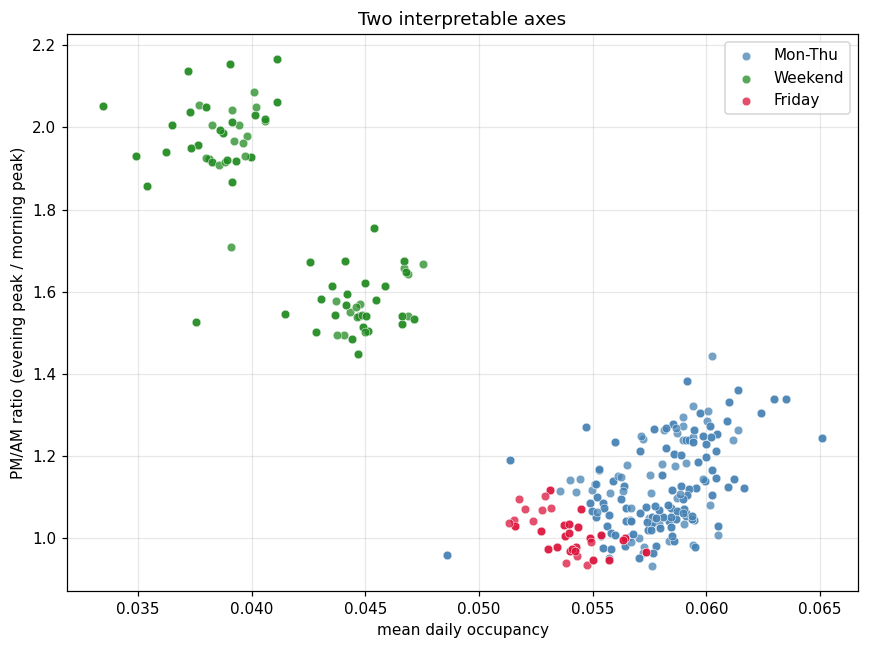

In [6]:
f_x = X.mean(axis=(1, 2))
f_y = (X[:, :, 90:126].mean(axis=(1, 2)) /
       (X[:, :, 30:66].mean(axis=(1, 2)) + 1e-8))

names3 = {1: 'Mon-Thu', 2: 'Friday', 3: 'Weekend'}
cols3 = {1: 'steelblue', 2: 'crimson', 3: 'forestgreen'}

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for k in [1, 3, 2]:
    m = gt == k
    ax.scatter(f_x[m], f_y[m], c=cols3[k], s=32, alpha=0.75,
               edgecolors='white', linewidths=0.4,
               label=names3[k], zorder=3 if k == 2 else 2)
ax.set_xlabel('mean daily occupancy')
ax.set_ylabel('PM/AM ratio (evening peak / morning peak)')
ax.set_title('Two interpretable axes')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bifiltration construction

In [7]:
K = 12
def knn_keys(F):
    nn = NearestNeighbors(n_neighbors=K + 1).fit(F)
    _, idx = nn.kneighbors(F); idx = idx[:, 1:]
    src = np.repeat(np.arange(N), K); dst = idx.ravel()
    a, b = np.minimum(src, dst), np.maximum(src, dst)
    return a.astype(np.int64) * N + b.astype(np.int64)

all_keys = np.unique(np.concatenate([knn_keys(F_temp), knn_keys(F_spat)]))
ei = (all_keys // N).astype(np.int64); ej = (all_keys % N).astype(np.int64)
edges = [(int(i), int(j)) for i, j in zip(ei, ej)]
w_temp = np.linalg.norm(F_temp[ei] - F_temp[ej], axis=1)
w_spat = np.linalg.norm(F_spat[ei] - F_spat[ej], axis=1)
w_temp = (w_temp / w_temp.max()).tolist()
w_spat = (w_spat / w_spat.max()).tolist()
filt_t = assemble_filtration(N, edges, w_temp)
filt_s = assemble_filtration(N, edges, w_spat)
adj = csr_matrix((np.ones(2 * len(edges)),
                  (np.r_[ei, ej], np.r_[ej, ei])), shape=(N, N))
print(f'edges: {len(edges)}')

edges: 6715


## Other methods, single-axis, bifiltration sweep

In [8]:
for F, fn in [(F_temp, 'KMeans(temporal)'),
              (F_spat, 'KMeans(spatial)'),
              (F_concat, 'KMeans(concat)')]:
    lab = KMeans(n_clusters=3, random_state=0, n_init=10).fit_predict(F)
    results.append(score(lab, gt, fn, 'baseline'))

for F, fn in [(F_temp, 'Ward+conn(temporal)'),
              (F_spat, 'Ward+conn(spatial)'),
              (F_concat, 'Ward+conn(concat)')]:
    lab = AgglomerativeClustering(n_clusters=3, linkage='ward',
                                  connectivity=adj).fit_predict(F)
    results.append(score(lab, gt, fn, 'baseline'))

sig = np.median(np.asarray(w_temp))
aff_v = np.exp(-(np.asarray(w_temp) / sig) ** 2)
aff = csr_matrix((np.r_[aff_v, aff_v],
                  (np.r_[ei, ej], np.r_[ej, ei])), shape=(N, N)).toarray()
np.fill_diagonal(aff, 1.0)
lab = SpectralClustering(n_clusters=3, affinity='precomputed',
                         random_state=0, n_init=10).fit_predict(aff)
results.append(score(lab, gt, 'Spectral(temporal)', 'baseline'))

for filt, fn in [(filt_t, 'temp-simplify'),
                 (filt_t, 'temp-persistence'),
                 (filt_s, 'spat-simplify'),
                 (filt_s, 'spat-persistence')]:
    method = 'simplify' if 'simplify' in fn else 'persistence'
    res = run_bifiltration_edges(N, filt, filt, method=method, n_clusters=3)
    results.append(score(res.labels_combined, gt, fn, 'single-axis-bif'))

for slope in [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
    for method, short in [('simplify', 'simplify'),
                          ('persistence', 'persistence')]:
        res = run_bifiltration_edges(N, filt_t, filt_s, method=method,
                                     n_clusters=3, slope=slope)
        results.append(score(res.labels_combined, gt,
                             f'Bif-{short} a={slope}', 'bifiltration'))

print(f'total methods evaluated: {len(results)}')

total methods evaluated: 29


In [9]:
print(f"{'method':32s} {'ARI':>7s} {'NMI':>6s}")
print('-' * 60)
for r in sorted(results, key=lambda r: -r['ari']):
    print(f"{r['name']:32s} {r['ari']:+.3f} {r['nmi']:.3f}")

method                               ARI    NMI
------------------------------------------------------------
temp-simplify                    +0.619 0.691
Bif-simplify a=2.0               +0.619 0.691
Bif-simplify a=4.0               +0.619 0.691
Bif-simplify a=8.0               +0.619 0.691
Spectral(temporal)               +0.619 0.691
1D KMeans: mean occupancy        +0.608 0.666
1D KMeans: PM/AM ratio           +0.554 0.596
1D KMeans: daily peak            +0.534 0.621
Bif-persistence a=1.0            +0.532 0.593
Ward+conn(temporal)              +0.515 0.668
KMeans(spatial)                  +0.509 0.612
KMeans(concat)                   +0.509 0.612
Ward+conn(spatial)               +0.501 0.589
Ward+conn(concat)                +0.501 0.589
Bif-persistence a=2.0            +0.496 0.600
Bif-simplify a=1.0               +0.490 0.572
temp-persistence                 +0.482 0.633
Bif-persistence a=4.0            +0.482 0.633
Bif-persistence a=8.0            +0.482 0.633
KMeans(temporal) 

## Pareto front (ARI × F1(Fri))

In [10]:
def pareto_mask(rows):
    pts = [(r['ari'], r['f1']) for r in rows]
    n = len(pts)
    on = np.ones(n, dtype=bool)
    for i in range(n):
        ai, fi = pts[i]
        for j in range(n):
            if i == j: continue
            a, f = pts[j]
            if a >= ai and f >= fi and (a > ai or f > fi):
                on[i] = False; break
    return on

results.sort(key=lambda r: (-r['ari'], -r['f1']))
on_front = pareto_mask(results)

## Per-axis comparison

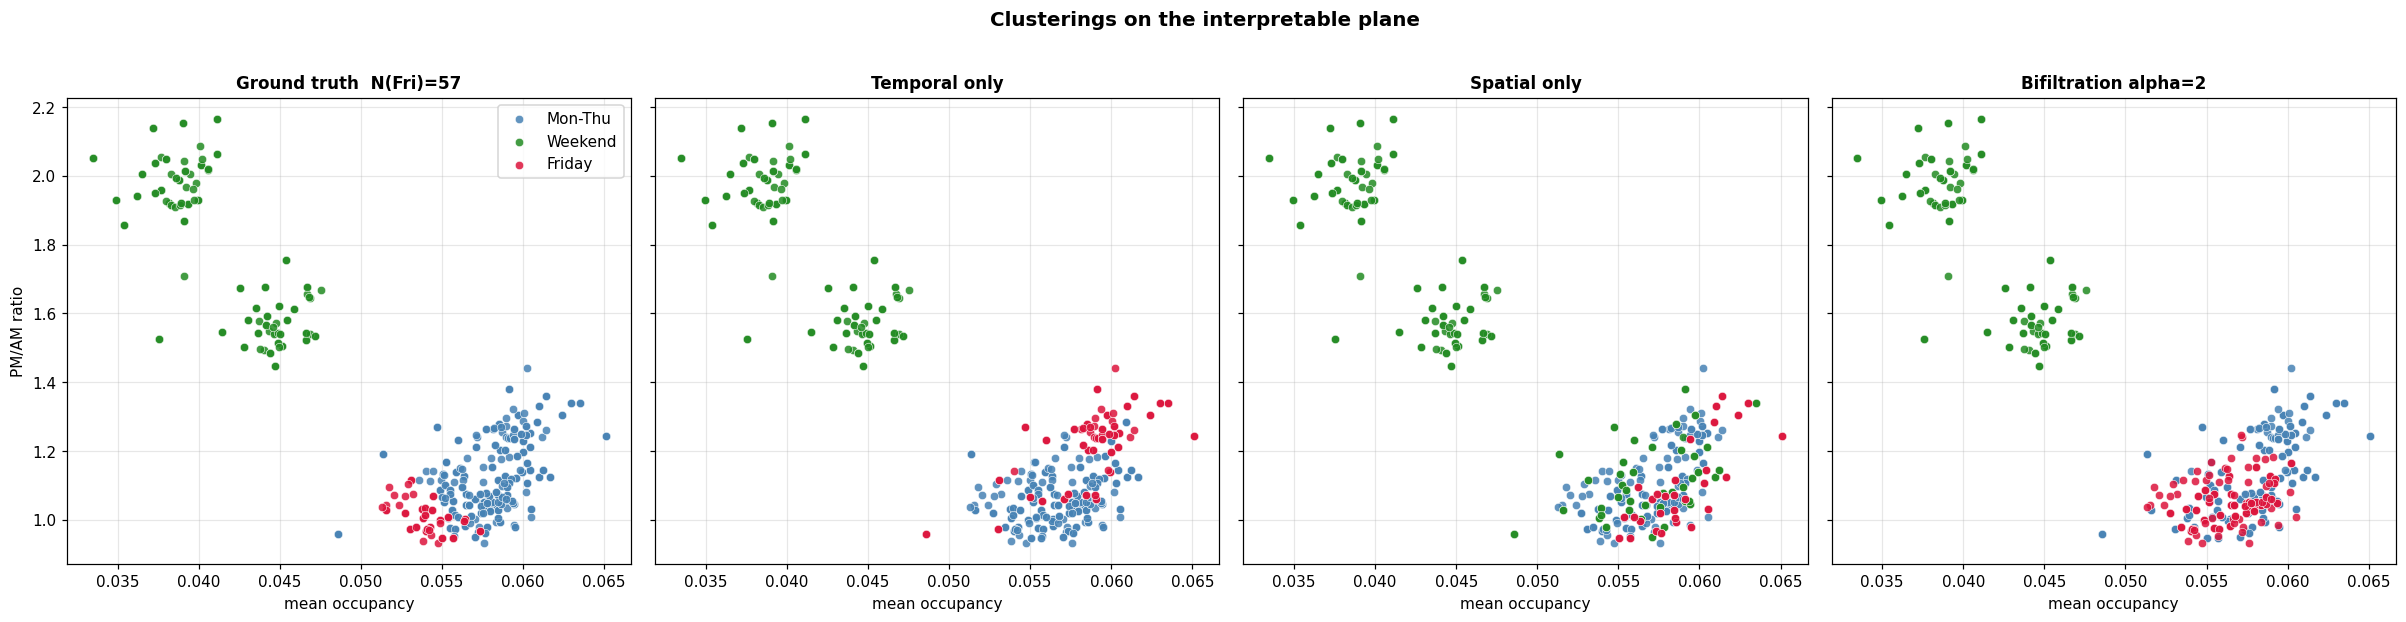

In [11]:
res_t = run_bifiltration_edges(N, filt_t, filt_t,
                              method='persistence', n_clusters=3)
res_s = run_bifiltration_edges(N, filt_s, filt_s,
                              method='persistence', n_clusters=3)
res_b = run_bifiltration_edges(N, filt_t, filt_s,
                              method='persistence', n_clusters=3, slope=2.0)
la_t, gt_norm = align_hungarian(res_t.labels_combined, gt)
la_s, _ = align_hungarian(res_s.labels_combined, gt)
la_b, _ = align_hungarian(res_b.labels_combined, gt)

def m3(la, gtn):
    ari = float(adjusted_rand_score(gtn, la))
    tp = int(((la == 2) & (gtn == 2)).sum())
    ng = int((gtn == 2).sum()); np_ = int((la == 2).sum())
    r = tp / ng if ng else 0.0
    p = tp / np_ if np_ else 0.0
    f1 = 2 * r * p / (r + p) if (r + p) > 0 else 0.0
    return ari, f1, r

at, ft, rt = m3(la_t, gt_norm)
asz, fs, rs = m3(la_s, gt_norm)
ab, fb, rb = m3(la_b, gt_norm)

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharex=True, sharey=True)
def panel(ax, lab, ttl, is_gt=False):
    for k in [1, 3, 2]:
        m = lab == k
        ax.scatter(f_x[m], f_y[m], c=cols3[k], s=30, alpha=0.85,
                   edgecolors='white', linewidths=0.4,
                   label=names3[k] if is_gt else None,
                   zorder=3 if k == 2 else 2)
    ax.set_xlabel('mean occupancy')
    ax.set_title(ttl, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

panel(axes[0], gt_norm, f'Ground truth  N(Fri)={int((gt_norm==2).sum())}', is_gt=True)
panel(axes[1], la_t, f'Temporal only')
panel(axes[2], la_s, f'Spatial only')
panel(axes[3], la_b, f'Bifiltration alpha=2')
axes[0].set_ylabel('PM/AM ratio')
axes[0].legend(loc='upper right')
fig.suptitle('Clusterings on the interpretable plane',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Same clusterings on PCA projections

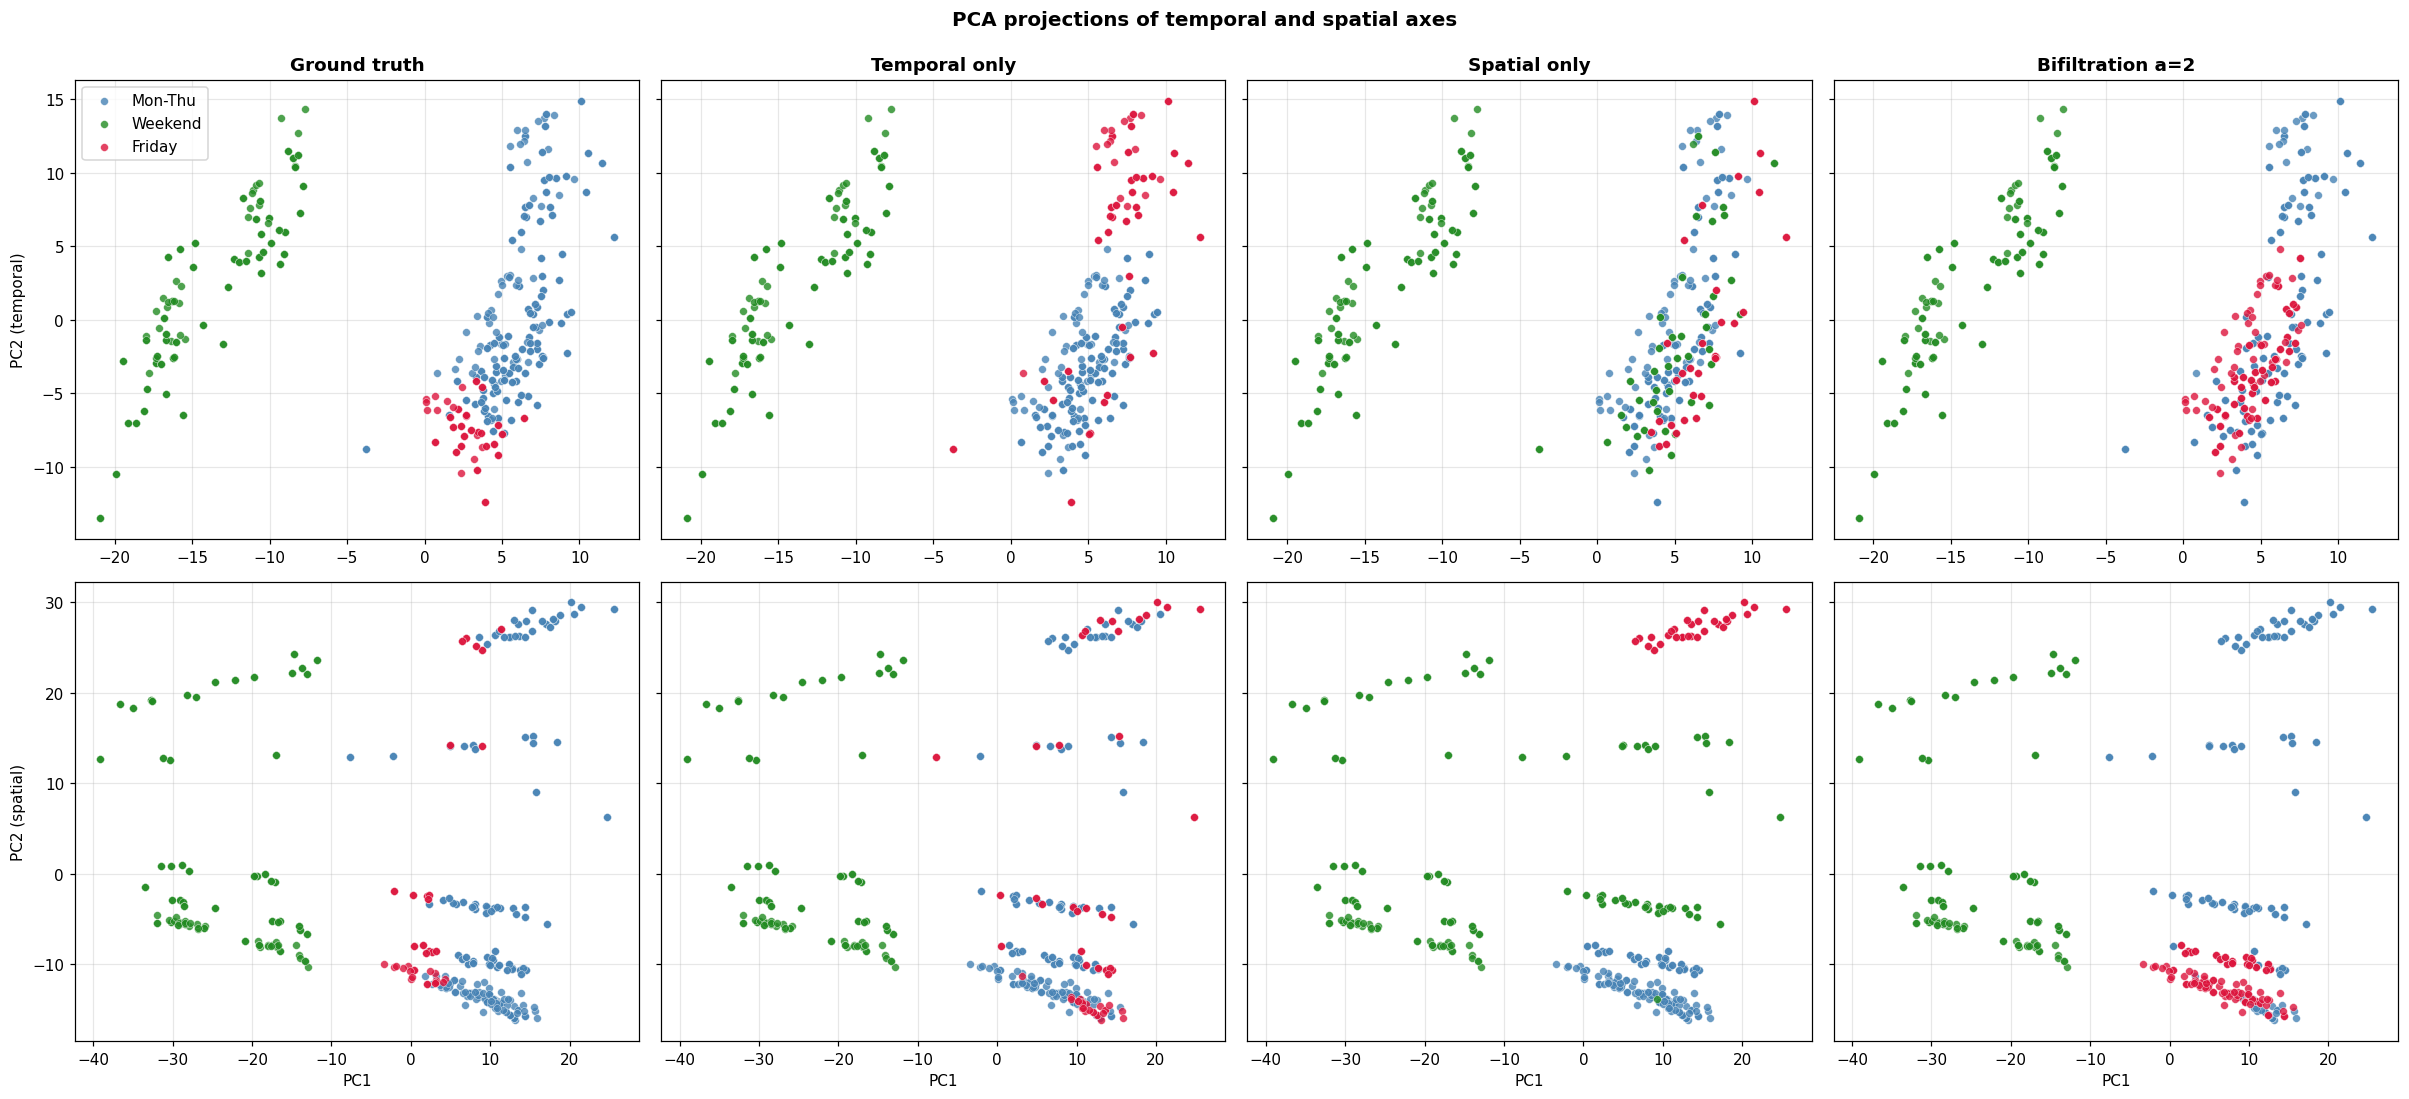

In [12]:
pca_t = PCA(n_components=2, random_state=0).fit(F_temp)
pca_s = PCA(n_components=2, random_state=0).fit(F_spat)
emb_t = pca_t.transform(F_temp)
emb_s = pca_s.transform(F_spat)

fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex='row', sharey='row')
labels_sets = [(gt_norm, 'Ground truth', True),
               (la_t, 'Temporal only', False),
               (la_s, 'Spatial only', False),
               (la_b, 'Bifiltration a=2', False)]
for col, (arr, ttl, is_gt) in enumerate(labels_sets):
    for k in [1, 3, 2]:
        m = arr == k
        axes[0, col].scatter(emb_t[m, 0], emb_t[m, 1], c=cols3[k],
                             s=26, alpha=0.8, edgecolors='white', linewidths=0.3,
                             label=names3[k] if is_gt else None,
                             zorder=3 if k == 2 else 2)
        axes[1, col].scatter(emb_s[m, 0], emb_s[m, 1], c=cols3[k],
                             s=26, alpha=0.8, edgecolors='white', linewidths=0.3,
                             zorder=3 if k == 2 else 2)
    axes[0, col].set_title(ttl, fontsize=12, fontweight='bold')
    axes[0, col].grid(alpha=0.3)
    axes[1, col].grid(alpha=0.3)
axes[0, 0].set_ylabel('PC2 (temporal)')
axes[1, 0].set_ylabel('PC2 (spatial)')
for c in range(4):
    axes[1, c].set_xlabel('PC1')
axes[0, 0].legend(loc='best')
fig.suptitle('PCA projections of temporal and spatial axes',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 7-way task (day of week)

In [13]:
F_spat_cos = F_spat / (np.linalg.norm(F_spat, axis=1, keepdims=True) + 1e-8)
D_spat_cos = cdist(F_spat_cos, F_spat_cos, metric='cosine')
w_spat_cos = D_spat_cos[ei, ej]
w_spat_cos = (w_spat_cos / w_spat_cos.max()).tolist()
filt_s_cos = assemble_filtration(N, edges, w_spat_cos)

res7_t = run_bifiltration_edges(N, filt_t, filt_t, method='simplify',
                               n_clusters=7)
res7_bL2 = run_bifiltration_edges(N, filt_t, filt_s, method='simplify',
                                  n_clusters=7, slope=4.0, min_size=11)
res7_bCos = run_bifiltration_edges(N, filt_t, filt_s_cos, method='simplify',
                                  n_clusters=7, slope=4.0)

y_int = y.astype(np.int64)
m_t,    la7_t    = all_metrics(res7_t.labels_combined,    y_int)
m_bL2,  la7_bL2  = all_metrics(res7_bL2.labels_combined,  y_int)
m_bCos, la7_bCos = all_metrics(res7_bCos.labels_combined, y_int)

lab_ward = AgglomerativeClustering(n_clusters=7, linkage='ward').fit_predict(F_temp)
m_ward, la7_ward = all_metrics(lab_ward, y_int)
lab_wc = AgglomerativeClustering(n_clusters=7, linkage='ward',
                                 connectivity=adj).fit_predict(F_temp)
m_wc, _ = all_metrics(lab_wc, y_int)

### Modern time-series clustering baselines

In [14]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sktime.transformations.panel.rocket import MiniRocketMultivariate

ts = X.mean(axis=1).reshape(N, 144, 1).astype(np.float32)
ts_n = TimeSeriesScalerMeanVariance().fit_transform(ts)

dk = TimeSeriesKMeans(n_clusters=7, metric='dtw', random_state=0,
                      n_init=2, max_iter=10, verbose=False)
lab_dtw = dk.fit_predict(ts_n)
m_dtw, _ = all_metrics(lab_dtw, y_int)

mr = MiniRocketMultivariate(random_state=0, num_kernels=10000)
feat = mr.fit_transform(X.astype(np.float32))
feat_arr = feat.values if hasattr(feat, 'values') else np.asarray(feat)
feat_s = StandardScaler().fit_transform(feat_arr)
feat_pca = PCA(n_components=50, random_state=0).fit_transform(feat_s)
lab_mr = KMeans(n_clusters=7, random_state=0, n_init=10).fit_predict(feat_pca)
m_mr, _ = all_metrics(lab_mr, y_int)

In [15]:
seven_way = [
    ('Bif-simp(temp only)', m_t),
    ('Bif-simp(temp x spat-L2)  a=4', m_bL2),
    ('Bif-simp(temp x spat-cos) a=4', m_bCos),
    ('Ward(temporal)', m_ward),
    ('Ward+conn(temporal)', m_wc),
    ('DTW k-means', m_dtw),
    ('MiniRocket + KMeans', m_mr),
]
print(f"{'method':32s} {'ARI':>7s} {'NMI':>6s}")
print('-' * 50)
for name, m in sorted(seven_way, key=lambda kv: -kv[1]['ari']):
    print(f"{name:32s} {m['ari']:+.3f} {m['nmi']:.3f}")

method                               ARI    NMI
--------------------------------------------------
Ward(temporal)                   +0.530 0.699
Ward+conn(temporal)              +0.530 0.699
Bif-simp(temp only)              +0.502 0.690
Bif-simp(temp x spat-L2)  a=4    +0.488 0.623
DTW k-means                      +0.406 0.596
Bif-simp(temp x spat-cos) a=4    +0.367 0.672
MiniRocket + KMeans              +0.175 0.318


In [16]:
_, gt7 = align_hungarian(res7_t.labels_combined, y_int)

def _sizes(lab):
    return sorted(Counter(lab.tolist()).values(), reverse=True)

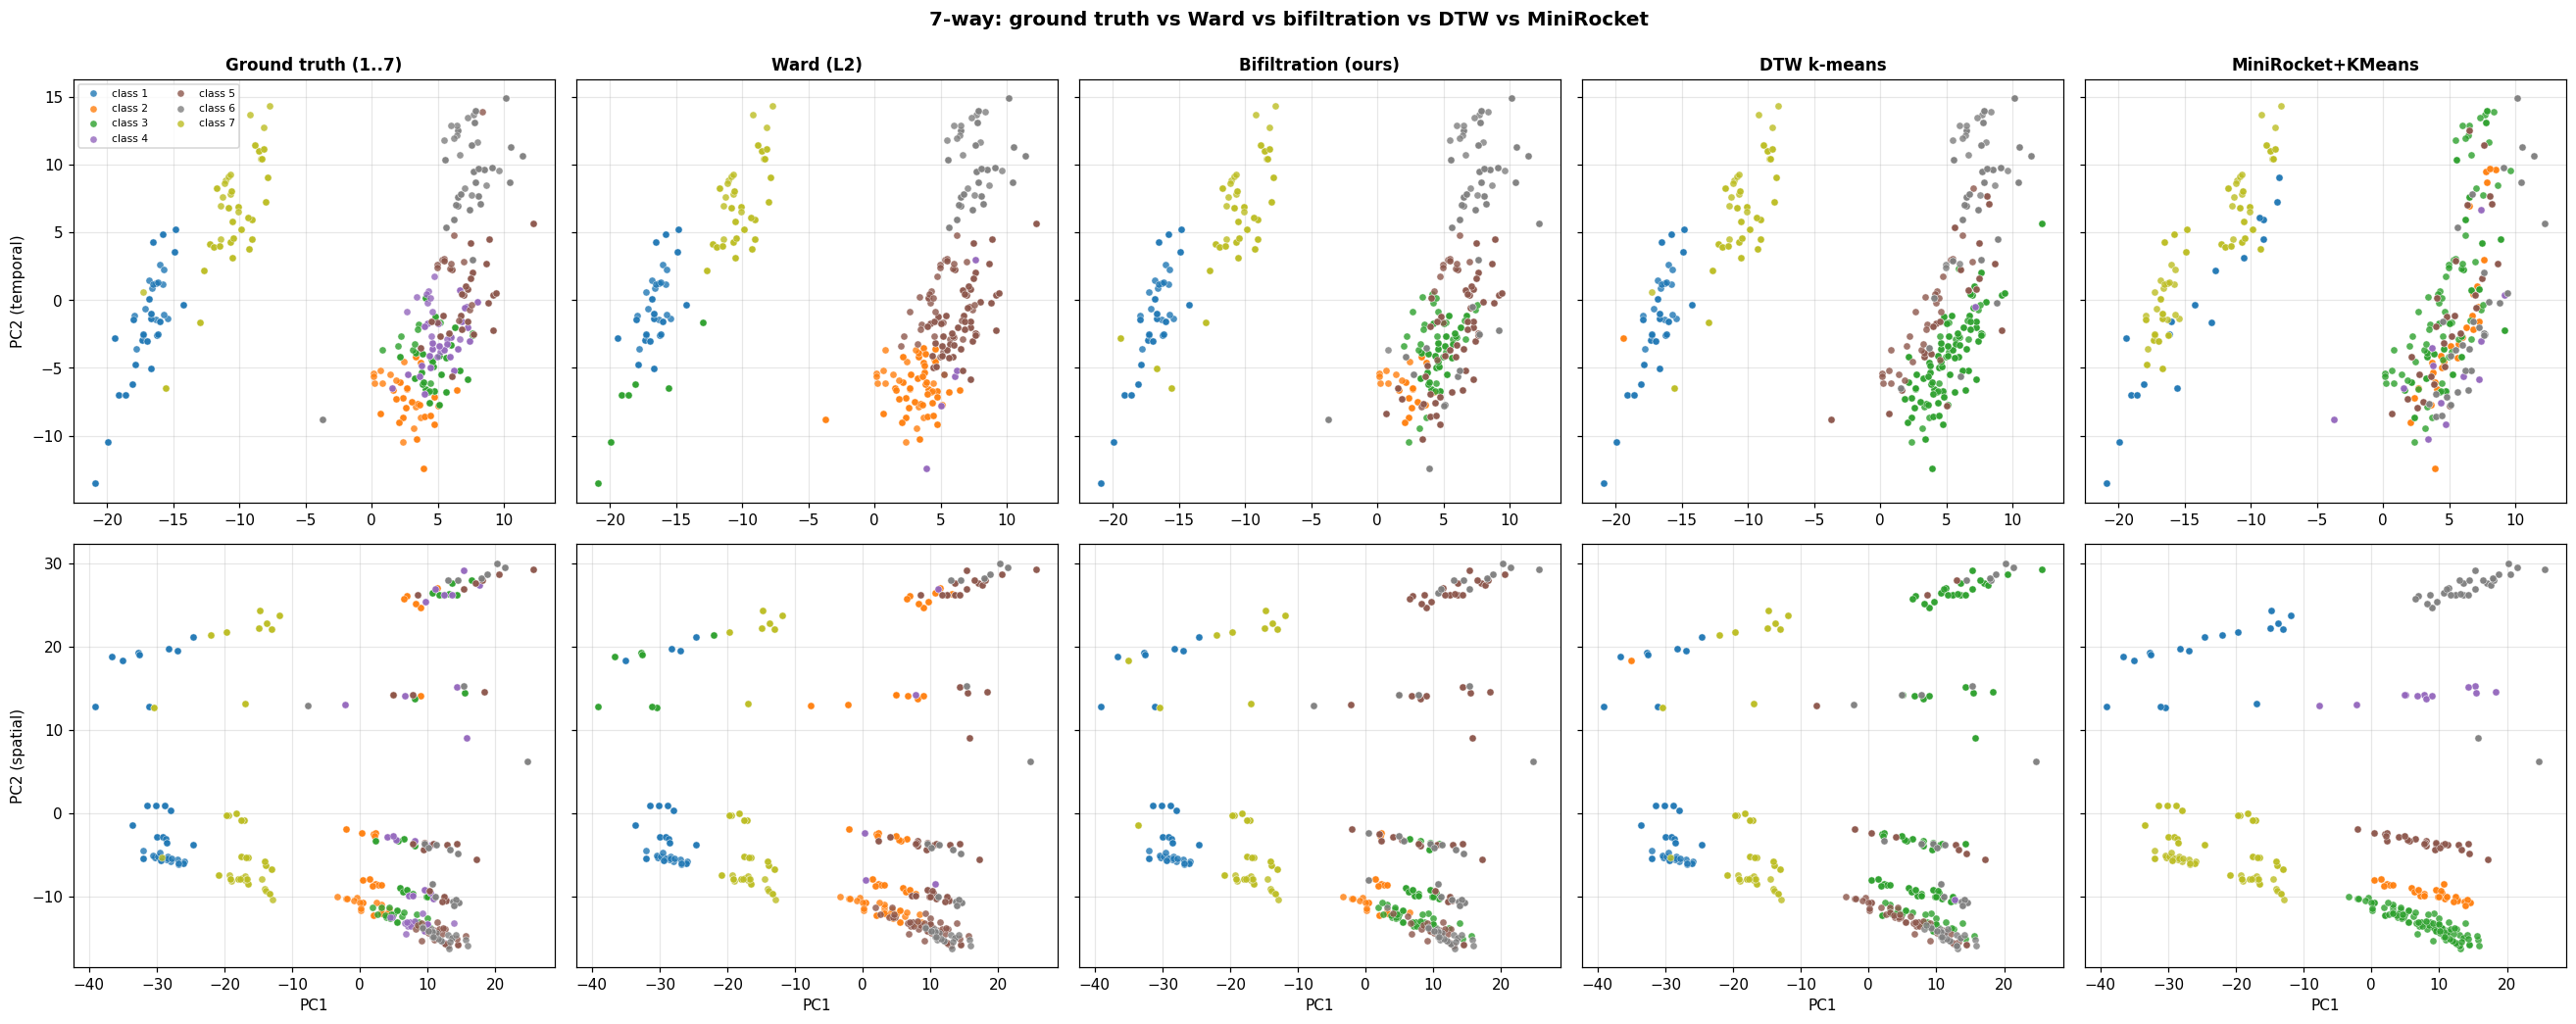

In [17]:
import matplotlib.cm as _cm
cmap7 = _cm.get_cmap('tab10')
cols7 = {k: cmap7((k - 1) / 7) for k in range(1, 8)}

la_ward_al, _ = align_hungarian(lab_ward, y_int)
la_dtw_al, _ = align_hungarian(lab_dtw.astype(np.int64), y_int)
la_mr_al, _ = align_hungarian(lab_mr.astype(np.int64), y_int)

sets7 = [(gt7, 'Ground truth (1..7)', True),
         (la_ward_al, 'Ward (L2)', False),
         (la7_bL2, 'Bifiltration (ours)', False),
         (la_dtw_al, 'DTW k-means', False),
         (la_mr_al, 'MiniRocket+KMeans', False)]

fig, axes = plt.subplots(2, 5, figsize=(24, 9.5), sharex='row', sharey='row')
for col, (arr, ttl, is_gt) in enumerate(sets7):
    for k in sorted(np.unique(arr)):
        m = arr == k
        axes[0, col].scatter(emb_t[m, 0], emb_t[m, 1], c=[cols7[k]],
                             s=22, alpha=0.8, edgecolors='white', linewidths=0.3,
                             label=f'class {k}' if is_gt else None, zorder=2)
        axes[1, col].scatter(emb_s[m, 0], emb_s[m, 1], c=[cols7[k]],
                             s=22, alpha=0.8, edgecolors='white', linewidths=0.3,
                             zorder=2)
    axes[0, col].set_title(ttl, fontsize=11, fontweight='bold')
    axes[0, col].grid(alpha=0.3)
    axes[1, col].grid(alpha=0.3)
axes[0, 0].set_ylabel('PC2 (temporal)')
axes[1, 0].set_ylabel('PC2 (spatial)')
for c in range(5): 
    axes[1, c].set_xlabel('PC1')
axes[0, 0].legend(loc='best', fontsize=7, ncol=2)
fig.suptitle('7-way: ground truth vs Ward vs bifiltration vs DTW vs MiniRocket',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

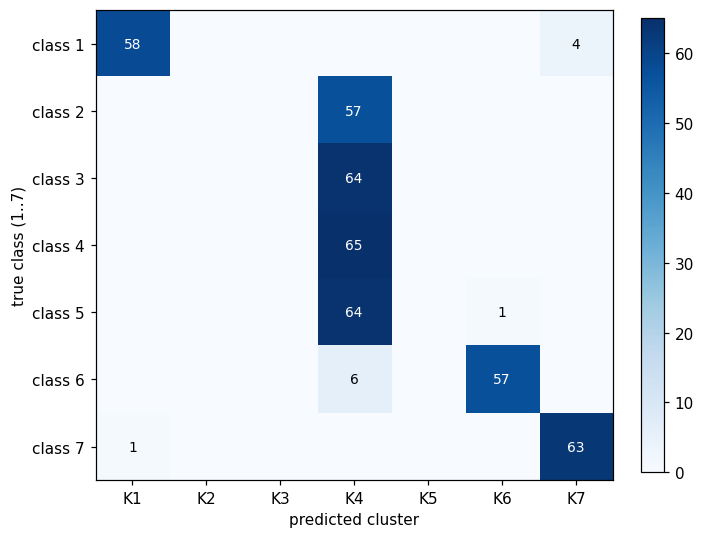

In [18]:
cm_bCos = confusion_matrix(gt7, la7_bCos)
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
im = ax.imshow(cm_bCos, cmap='Blues', aspect='auto')
ax.set_xticks(range(cm_bCos.shape[1]))
ax.set_yticks(range(cm_bCos.shape[0]))
ax.set_xticklabels([f'K{k+1}' for k in range(cm_bCos.shape[1])])
ax.set_yticklabels([f'class {k+1}' for k in range(cm_bCos.shape[0])])
ax.set_xlabel('predicted cluster')
ax.set_ylabel('true class (1..7)')
for i in range(cm_bCos.shape[0]):
    for j in range(cm_bCos.shape[1]):
        v = cm_bCos[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center',
                    color='white' if v > cm_bCos.max() / 2 else 'black',
                    fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()